In [42]:
import pandas as pd

df = pd.read_csv('Cafe.csv')

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   str    
 1   datetime     3636 non-null   str    
 2   cash_type    3636 non-null   str    
 3   card         3547 non-null   str    
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   str    
dtypes: float64(1), str(5)
memory usage: 170.6 KB


In [44]:
df.describe()

,money
count,3636.000000
mean,31.746859
std,4.919926
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,40.000000


In [45]:
df.dtypes

date               str
datetime           str
cash_type          str
card               str
money          float64
coffee_name        str
dtype: object

In [46]:
df.nunique()

date            381
datetime       3636
cash_type         2
card           1316
money            20
coffee_name       8
dtype: int64

In [47]:
df.shape

(3636, 6)

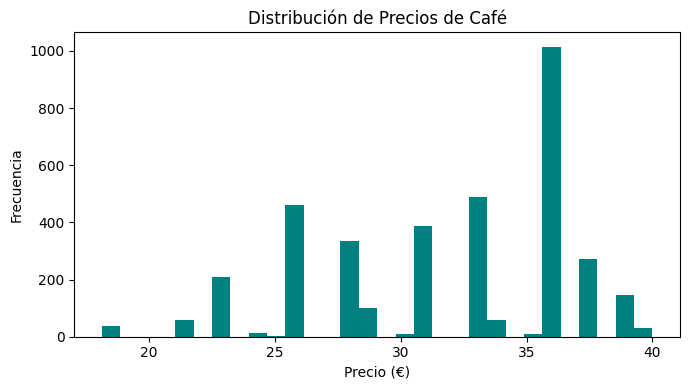

In [48]:

import matplotlib.pyplot as plt

# plt es el panel de dibujo 
# plt.subplots crea una figura fig y un eje ax
# plt.tight_layout ajusta margenes y espacios
# plt.show dibuja de verdad, lo muestra en pantalla

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Cafe.csv')

plt.figure(figsize=(7, 4))
plt.hist(df['money'], bins=30, color= 'teal', )
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Precios de Café')
plt.tight_layout()
plt.savefig('histograma.png')
plt.show()

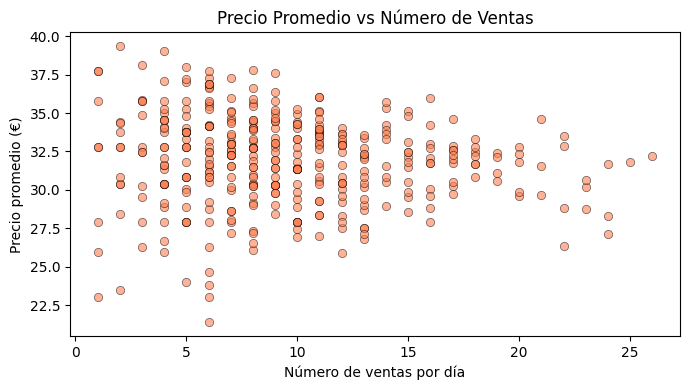

In [49]:
# creo un scatter los datos por fecha y calcula dos métricas derivadas: el precio promedio y el número de ventas por día, luego 
# las hace un plot para ver si hay relación entre volumen de ventas y precio promedio

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Cafe.csv')

# Agrupo por fecha y calcular datos derivados por el groupby
ventas_por_dia = df.groupby('date').agg({
'money': ['mean', 'count']
}).reset_index()

ventas_por_dia.columns = ['date', 'precio_promedio', 'num_ventas']

# Creo scatterplot
plt.figure(figsize=(7, 4))
plt.scatter(ventas_por_dia['num_ventas'], ventas_por_dia['precio_promedio'], 
c='coral', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('Número de ventas por día')
plt.ylabel('Precio promedio (€)')
plt.title('Precio Promedio vs Número de Ventas')
plt.tight_layout()
plt.savefig('scatter.png')
plt.show()

<Figure size 1000x500 with 0 Axes>

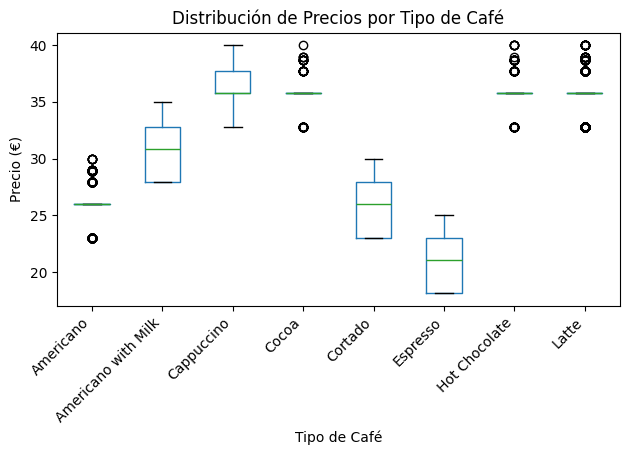

In [50]:
# Boxplot de stars por has_ci (0 = no, 1 = sí). Esta es la de los bigotes? percentiles?
# Creas la figura en las dos primeras lineas con los dos primeros grupos de sí ci y no ci
# Para cada grupo, coges la lista de stars que cumplen esa condición de su grupo
# Pones el eje Y en log para manejar los valores grandes
# En el tercer bloque de lineas de código, etiquetas títulos
# plt.tight_layout ajusta margenes y espacios

# muestra la distribución de precios para cada uno de los 8 tipos de café. Compara visualmente

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Cafe.csv')

plt.figure(figsize=(10, 5))
df.boxplot(column='money', by='coffee_name', grid=False)
plt.xlabel('Tipo de Café')
plt.ylabel('Precio (€)')
plt.title('Distribución de Precios por Tipo de Café')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot.png')
plt.show()

<Figure size 700x500 with 0 Axes>

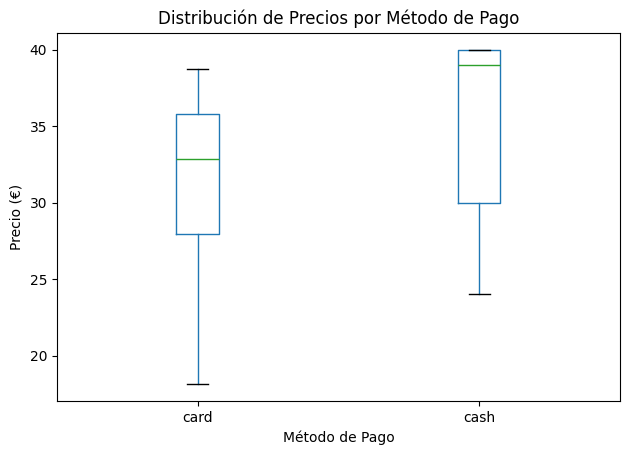

In [51]:
# otro boxplot comparando precios según el método de pago.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Cafe.csv')

plt.figure(figsize=(7, 5))
df.boxplot(column='money', by='cash_type', grid=False)
plt.xlabel('Método de Pago')
plt.ylabel('Precio (€)')
plt.title('Distribución de Precios por Método de Pago')
plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplot_pago.png')
plt.show()

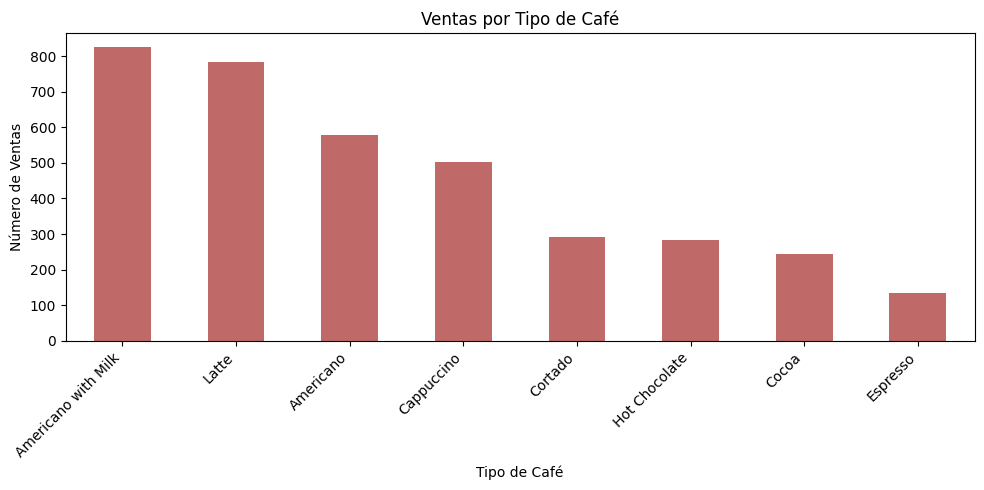

In [52]:
# aquí cuento venta por tipo de café

# 4. Barras: proporción de repos con CI, wiki, discussions
# aquí construyo un gráfico de barras que muestra qué porcentaje de repos tiene ci, wiki y discussions
# bool_cools define una lista con los nombres
# df.bool_cool solo selecciona esas columnas y mean calcula la media. acuerdate , como la lista del df.describe
# la segunda parte configura xy y los títulos que quieras darle
# ascending le dice a pandas en que orden (de mayor a menor) ordenar. que me acuerdo de ale que lo dijo.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Cafe.csv')

ventas = df['coffee_name'].value_counts()

plt.figure(figsize=(10, 5))
ventas.plot(kind='bar', color='brown', alpha=0.7)
plt.xlabel('Tipo de Café')
plt.ylabel('Número de Ventas')
plt.title('Ventas por Tipo de Café')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('barras.png')
plt.show()

In [1]:
# voy a clasificar en coffee usando hora, importe, metodo de pago como features, con KNN

import pandas as pd

# Cargo datos, aseguro que datatime es tipo fecha-hora
# Creo variables de tiempo, y elijo target
# Elijo numéricas básicas y transformo cash_types a dummies
df = pd.read_csv("Cafe.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday  # 0=lunes, 6=domingo

y = df["coffee_name"]
X = df[["money", "hour", "weekday", "cash_type"]].copy()

X = pd.get_dummies(X, columns=["cash_type"], drop_first=False)


In [54]:
# aqui y es multiclase por los varios tipos de cafe y por eso encaja el KNN
# transformo cash_type a códigos numéricos con nuestros amiguitos get_dummies

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [55]:
# esto es knn!
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("Cafe.csv")

df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday

y = df["coffee_name"]
X = df[["money", "hour", "weekday", "cash_type"]].copy()

print("Antes de dummies:", X.columns)

X = pd.get_dummies(X, columns=["cash_type"], drop_first=False)

print("Después de dummies:", X.columns)

# Train / test
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# KNN (vecinos cercanos)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# el modelo acierta un 50% . 0.76 esta bien, expresso tiene 0.95 que esta mejor pero recall peor
# cocoa no lo diferencia porque no es un cafe.

Antes de dummies: Index(['money', 'hour', 'weekday', 'cash_type'], dtype='str')
Después de dummies: Index(['money', 'hour', 'weekday', 'cash_type_card', 'cash_type_cash'], dtype='str')
Accuracy: 0.5041208791208791
                     precision    recall  f1-score   support

          Americano       0.59      0.68      0.63       111
Americano with Milk       0.73      0.80      0.76       170
         Cappuccino       0.34      0.45      0.39        99
              Cocoa       0.20      0.24      0.22        42
            Cortado       0.31      0.25      0.28        51
           Espresso       0.95      0.67      0.78        30
      Hot Chocolate       0.20      0.20      0.20        49
              Latte       0.48      0.33      0.39       176

           accuracy                           0.50       728
          macro avg       0.48      0.45      0.46       728
       weighted avg       0.51      0.50      0.50       728



In [56]:
import pandas as pd

# Cargo el dataset de café
df = pd.read_csv("Cafe.csv")

# creo variables de tiempo a partir de datetime
df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday  # 0 = lunes, 6 = domingo

# Coffee_name 
df = pd.get_dummies(df, columns=["coffee_name"], drop_first=True)

df.head()

,date,datetime,cash_type,card,money,hour,weekday,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,10,4,False,False,False,False,False,False,True
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,12,4,False,False,False,False,False,True,False
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,12,4,False,False,False,False,False,True,False
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,13,4,False,False,False,False,False,False,False
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,13,4,False,False,False,False,False,False,True


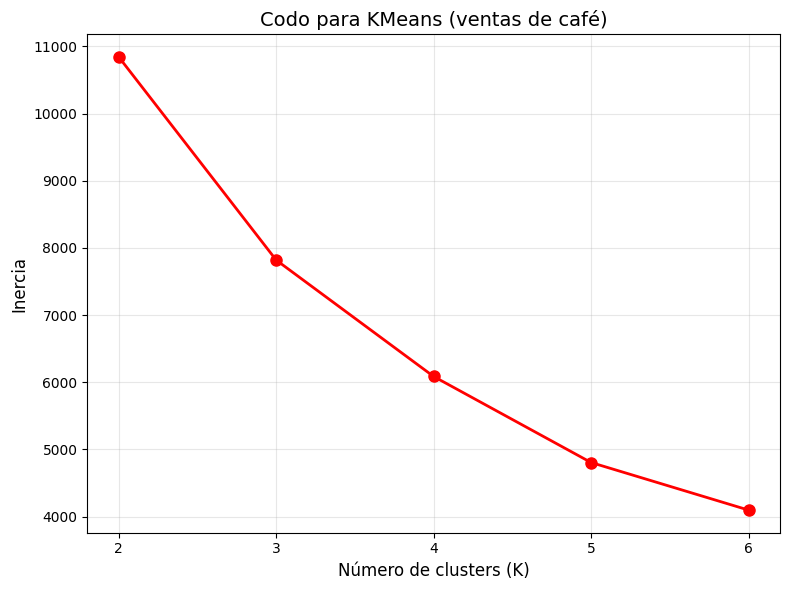

         date  money cash_type  hour  weekday    coffee_name  Cluster
0  2024-03-01   38.7      card    10        4          Latte        1
1  2024-03-01   38.7      card    12        4  Hot Chocolate        1
2  2024-03-01   38.7      card    12        4  Hot Chocolate        1
3  2024-03-01   28.9      card    13        4      Americano        2
4  2024-03-01   38.7      card    13        4          Latte        1


In [57]:
# aqui he hecho el codo
# el dataset iris es el mas facil y basico de todos
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Cafe.csv")

# Creo features de tiempo
df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
# 0 = lunes, 6 = domingo

# Elijo variables para clustering
#    money, hour, weekday y método de pago (cash_type → dummies)
X = df[["money", "hour", "weekday", "cash_type"]].copy()
X = pd.get_dummies(X, columns=["cash_type"], drop_first=False)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#  Codo
inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

k_values = np.arange(2, 7)
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Codo para KMeans (ventas de café)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clusters
kmeans_cafe = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans_cafe.fit_predict(X_scaled)

# miro cómo quedan los primeros registros:
print(df[["date", "money", "cash_type", "hour", "weekday", "coffee_name", "Cluster"]].head())

In [58]:
clusters = KMeans(3, n_init=10).fit_predict(X_scaled)
df['Cluster'] = clusters
df.head()

,date,datetime,cash_type,card,money,coffee_name,hour,weekday,Cluster
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10,4,1
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,4,1
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,4,1
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,13,4,0
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,13,4,1


In [59]:
import pandas as pd

df = pd.read_csv("Cafe.csv")

# Añado variables numéricas derivadas de datetime
df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday  # 0 = lunes, 6 = domingo

# Coffee_name sería columna categórica que la paso a dummies
df = pd.get_dummies(df, columns=["coffee_name"], drop_first=True)

# Escalo manual(money, hour, weekday y dummies de cash_type si quieres)
X = df[["money", "hour", "weekday", "cash_type"]].copy()
X = pd.get_dummies(X, columns=["cash_type"], drop_first=False)

X_scaled = (X - X.mean()) / X.std()  # estándar: media 0, varianza 1

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("Cafe.csv")

# Creo variables de tiempo.  0=lunes, 6=domingo
df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday  

# Me quedo con las features para PCA
X = df[["money", "hour", "weekday", "cash_type"]].copy()
X = pd.get_dummies(X, columns=["cash_type"], drop_first=False)

# Guardo las etiquetas de café, que se me olvidan
coffee_labels = df["coffee_name"].copy()

# Escalo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:",
      pca.explained_variance_ratio_)
print("Varianza explicada acumulada:",
      pca.explained_variance_ratio_.cumsum())

# DataFrame PCA + tipo de café
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["coffee_name"] = coffee_labels

df_pca.head()

Varianza explicada por cada componente: [0.40660486 0.23675402]
Varianza explicada acumulada: [0.40660486 0.64335888]


,PC1,PC2,coffee_name
0,0.035708,0.205684,Latte
1,0.033337,0.552676,Hot Chocolate
2,0.033337,0.552676,Hot Chocolate
3,-0.316072,-0.602129,Americano
4,0.032151,0.726172,Latte


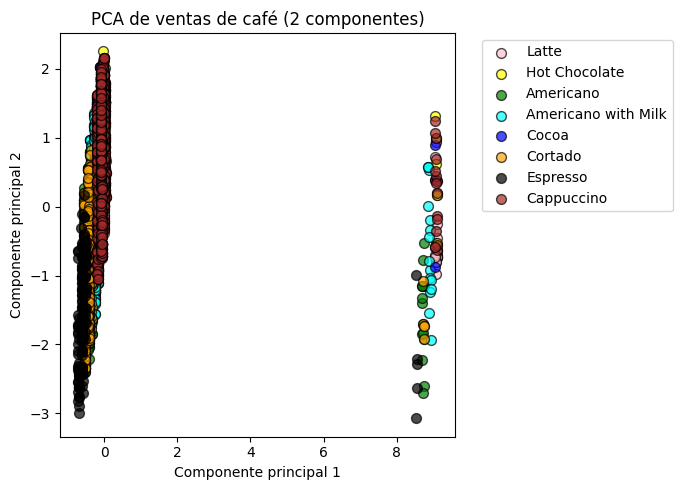

In [61]:
# Primero he estandarizado las variables numéricas del café (money, hour, weekday y las dummies de cash_type) para que todas tengan media 0 y desviación estándar 1, porque PCA es sensible a la escala.
# Luego he aplicado PCA con 2 componentes, he ajustado el modelo sobre X_scaled (los datos de café estandarizados) y he transformado los datos para obtener X_pca con solo 2 columnas (PC1 y PC2).
# He consultado explained_variance_ratio_ y su suma acumulada para ver qué porcentaje de la varianza total de las ventas de café explican PC1 y PC2, y así comprobar cuánta información mantienen esos dos componentes.
# He hecho un scatter de PC1 vs PC2 coloreando por coffee_name para comprobar si ciertos tipos de café (por ejemplo, espressos, lattes, etc.) tienden a agruparse en el plano PCA según su precio, la hora, el día de la semana y el método de pago.import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

colores = ['pink', 'yellow', 'green', 'cyan', 'blue', 'orange', 'black', 'brown']

for color, coffee in zip(colores, df_pca["coffee_name"].unique()):
    subset = df_pca[df_pca["coffee_name"] == coffee]
    plt.scatter(
subset["PC1"],
subset["PC2"],
c=color,
label=coffee,
alpha=0.7,
edgecolors='k',
s=50)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('PCA de ventas de café (2 componentes)')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()